In [1]:
!pip install --upgrade keras-hub keras-nlp keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 95.0 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.10.0
    Uninstalling keras-3.10.0:
      Successfully uninstalled keras-3.10.0
  Attempting uninstall: keras-hub
    Found existing installation: keras-hub 0.21.1
    Uninstalling keras-hub-0.21.1:
      Successfully uninstalled keras-hub-0.21.1
  Attempting uninstall: keras-nlp
    Found existing installation: keras-nlp 0.21.1
    Uninstalling keras-nlp-0.21.1:
      Successfully uninstalled keras-nlp-0.21.1


In [2]:
!nvidia-smi

Tue Mar  3 19:20:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import keras as kr
import seaborn as sb
import sklearn
import tensorflow as tf
import keras_hub as kr_h
from keras.preprocessing.sequence import pad_sequences
from keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sklearn.set_config(transform_output="pandas")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd /content/drive/My Drive/Bible_nn/

/content/drive/My Drive/Bible_nn


In [6]:
in_file=open("bible_ready.txt","r", errors='ignore',encoding='utf8')
text=in_file.read()
in_file.close()
T=text.split("\n")
ord_len=len(T)
print(T)

['na', 'początku', 'bóg', 'stworzył', 'niebo', 'i', 'ziemię', 'a', 'ziemia', 'była', 'bezkształtna', 'i', 'pusta', 'i', 'ciemność', 'była', 'nad', 'głębią', 'a', 'duch', 'boży', 'unosił', 'się', 'nad', 'wodami', 'i', 'bóg', 'powiedział', 'niech', 'stanie', 'się', 'światłość', 'i', 'stała', 'się', 'światłość', 'bóg', 'widział', 'że', 'światłość', 'była', 'dobra', 'i', 'oddzielił', 'bóg', 'światłość', 'od', 'ciemności', 'i', 'nazwał', 'bóg', 'światłość', 'dniem', 'a', 'ciemność', 'nazwał', 'nocą', 'i', 'nastał', 'wieczór', 'i', 'poranek', 'dzień', 'pierwszy', 'potem', 'bóg', 'powiedział', 'niech', 'stanie', 'się', 'firmament', 'pośrodku', 'wód', 'i', 'niech', 'oddzieli', 'wody', 'od', 'wód', 'i', 'uczynił', 'bóg', 'firmament', 'i', 'oddzielił', 'wody', 'które', 'są', 'pod', 'firmamentem', 'od', 'wód', 'które', 'są', 'nad', 'firmamentem', 'i', 'tak', 'się', 'stało', 'i', 'bóg', 'nazwał', 'firmament', 'niebem', 'i', 'nastał', 'wieczór', 'i', 'poranek', 'dzień', 'drugi', 'potem', 'bóg', 'po

In [7]:
WS=np.array(sorted(set(T)))
ws_len=len(WS)+1
word_to_id = {word: i+1 for i, word in enumerate(WS)}
id_to_word = {i+1: word for i, word in enumerate(WS)}
print(id_to_word)

{1: np.str_('a'), 2: np.str_('aaron'), 3: np.str_('aarona'), 4: np.str_('aaronem'), 5: np.str_('aaronie'), 6: np.str_('aaronitami'), 7: np.str_('aaronowi'), 8: np.str_('abaddon'), 9: np.str_('abagcie'), 10: np.str_('abana'), 11: np.str_('abarim'), 12: np.str_('abba'), 13: np.str_('abda'), 14: np.str_('abdeel'), 15: np.str_('abdeela'), 16: np.str_('abdi'), 17: np.str_('abdiasz'), 18: np.str_('abdiasza'), 19: np.str_('abdiego'), 20: np.str_('abdiela'), 21: np.str_('abdon'), 22: np.str_('abdonowi'), 23: np.str_('abdy'), 24: np.str_('abed-nego'), 25: np.str_('abel'), 26: np.str_('abel-bet-maaka'), 27: np.str_('abel-mechola'), 28: np.str_('abel-szittim'), 29: np.str_('abelmaim'), 30: np.str_('abelu'), 31: np.str_('abi'), 32: np.str_('abi-albon'), 33: np.str_('abia'), 34: np.str_('abiasaf'), 35: np.str_('abiasz'), 36: np.str_('abiasza'), 37: np.str_('abiaszem'), 38: np.str_('abiatar'), 39: np.str_('abiatara'), 40: np.str_('abiatarem'), 41: np.str_('abiatarowi'), 42: np.str_('abib'), 43: np.s

In [8]:
freq={word:0 for word in WS}
for t in T:
    freq[t]+=1
asc = {k: 100*v/len(T) for k, v in sorted(freq.items(), key=lambda item: item[1],reverse=True)}
freq

{np.str_('a'): 10363,
 np.str_('aaron'): 115,
 np.str_('aarona'): 193,
 np.str_('aaronem'): 9,
 np.str_('aaronie'): 2,
 np.str_('aaronitami'): 1,
 np.str_('aaronowi'): 32,
 np.str_('abaddon'): 1,
 np.str_('abagcie'): 1,
 np.str_('abana'): 1,
 np.str_('abarim'): 4,
 np.str_('abba'): 3,
 np.str_('abda'): 1,
 np.str_('abdeel'): 2,
 np.str_('abdeela'): 1,
 np.str_('abdi'): 1,
 np.str_('abdiasz'): 5,
 np.str_('abdiasza'): 3,
 np.str_('abdiego'): 2,
 np.str_('abdiela'): 1,
 np.str_('abdon'): 7,
 np.str_('abdonowi'): 1,
 np.str_('abdy'): 1,
 np.str_('abed-nego'): 15,
 np.str_('abel'): 6,
 np.str_('abel-bet-maaka'): 2,
 np.str_('abel-mechola'): 3,
 np.str_('abel-szittim'): 1,
 np.str_('abelmaim'): 1,
 np.str_('abelu'): 1,
 np.str_('abi'): 1,
 np.str_('abi-albon'): 1,
 np.str_('abia'): 1,
 np.str_('abiasaf'): 1,
 np.str_('abiasz'): 14,
 np.str_('abiasza'): 8,
 np.str_('abiaszem'): 2,
 np.str_('abiatar'): 9,
 np.str_('abiatara'): 19,
 np.str_('abiatarem'): 1,
 np.str_('abiatarowi'): 2,
 np.str_(

In [ ]:
#wei = [0.0]+[v/len(T) for v in freq.values()]
#wei

In [9]:
wei=[0]+[1]*len(T)

In [ ]:
#sq=[0.0]+[1.0/math.log2(v+1) for v in freq.values()]
#wei=[v/sum(sq) for v in sq]
#wei

In [ ]:
#anty = [0.0]+[len(T)/math.sqrt(v) for v in freq.values()]
#wei=[v/sum(anty) for v in anty]
#wei
#sum(wei)

In [10]:
ordered_ids = [word_to_id[w] for w in T]
ordered_ids

[10918,
 17289,
 1925,
 26267,
 12225,
 6640,
 36706,
 1,
 36699,
 1905,
 1223,
 6640,
 22052,
 6640,
 2803,
 1905,
 11051,
 6360,
 1,
 4526,
 1616,
 29219,
 24553,
 11051,
 31078,
 6640,
 1925,
 19172,
 12227,
 25771,
 24553,
 38477,
 6640,
 25916,
 24553,
 38477,
 1925,
 30633,
 38645,
 38477,
 1905,
 3758,
 6640,
 14048,
 1925,
 38477,
 13842,
 2800,
 6640,
 12044,
 1925,
 38477,
 3747,
 1,
 2803,
 12044,
 12927,
 6640,
 11819,
 30688,
 6640,
 18425,
 4787,
 16668,
 18950,
 1925,
 19172,
 12227,
 25771,
 24553,
 5393,
 19722,
 33907,
 6640,
 12227,
 14044,
 31084,
 13842,
 33907,
 6640,
 28558,
 1925,
 5393,
 6640,
 14048,
 31084,
 8792,
 27121,
 17302,
 5394,
 13842,
 33907,
 8792,
 27121,
 11051,
 5394,
 6640,
 27446,
 24553,
 25924,
 6640,
 1925,
 12044,
 5393,
 12203,
 6640,
 11819,
 30688,
 6640,
 18425,
 4787,
 4452,
 18950,
 1925,
 19172,
 12227,
 24553,
 35914,
 30247,
 7176,
 10080,
 31084,
 8792,
 27121,
 17302,
 12203,
 6640,
 12227,
 24553,
 28838,
 26306,
 19203,
 6640,

In [ ]:
"""
SEQ_CHUNK = 10
embed_dim = 100
head_dim=4
mlp_dim=embed_dim*4
sequences = []
for i in range(0, len(ordered_ids), SEQ_CHUNK):
    chunk = ordered_ids[i : i + SEQ_CHUNK]
    if len(chunk) > 1:
        sequences.append(chunk)
X_list = [seq[:-1] for seq in sequences]
y_list = [seq[1:]  for seq in sequences]
X = pad_sequences(X_list, padding='post', value=0)
y = pad_sequences(y_list, padding='post', value=0)
X_t,y_t,_,_=train_test_split(X,y,test_size=0.8)
len(X_list)
"""

58341

In [10]:
SEQ_CHUNK = 10
embed_dim = 100
head_dim=4
mlp_dim=embed_dim*4
sequences = []
for i in range(0, len(ordered_ids), SEQ_CHUNK):
    chunk = ordered_ids[i : i + SEQ_CHUNK+1]
    if len(chunk) > 1:
        sequences.append(chunk)
X_list = [seq[:-1] for seq in sequences]
y_list = [seq[1:]  for seq in sequences]
X = pad_sequences(X_list, padding='post', value=0)
y = pad_sequences(y_list, padding='post', value=0)
X_t,y_t,_,_=train_test_split(X,y,test_size=0.8)
len(X_list)

58341

In [11]:
SEQ_CHUNK = 10
embed_dim = 100
head_dim=4
mlp_dim=embed_dim*4
sequences = []
for i in range(0, len(ordered_ids), 1):
    chunk = ordered_ids[i : i + SEQ_CHUNK+1]
    if len(chunk) > 1:
        sequences.append(chunk)
X_list = [seq[:-1] for seq in sequences]
y_list = [seq[1:]  for seq in sequences]
X2 = pad_sequences(X_list, padding='post', value=0)
y2 = pad_sequences(y_list, padding='post', value=0)


In [12]:
def sparse_focal_loss_fixed(y_true, y_pred, gamma=2.0, alpha=0.25):
    # y_pred: (batch, steps, vocab_size)
    # y_true: (batch, steps) -> indeksy

    # 1. Pobieramy prawdopodobieństwa tylko dla prawdziwych klas (zamiast one-hot)
    # tf.gather_nd lub batch_gather jest tu potrzebne, ale najprościej spłaszczyć:

    vocab_size = tf.shape(y_pred)[-1]
    y_pred_flat = tf.reshape(y_pred, [-1, vocab_size])
    y_true_flat = tf.reshape(y_true, [-1])
    y_true_flat = tf.cast(y_true_flat, tf.int32)

    # Zapobiegamy błędom numerycznym (log(0))
    epsilon = 1e-7
    y_pred_flat = tf.clip_by_value(y_pred_flat, epsilon, 1. - epsilon)

    # Wyciągamy p_t (prawdopodobieństwo klasy poprawnej)
    # Tworzymy indeksy [0, 1, 2...] dla batcha
    indices = tf.stack([tf.range(tf.shape(y_true_flat)[0]), y_true_flat], axis=1)
    p_t = tf.gather_nd(y_pred_flat, indices)

    # Wzór Focal Loss: -alpha * (1 - p_t)^gamma * log(p_t)
    loss = -alpha * tf.math.pow((1 - p_t), gamma) * tf.math.log(p_t)

    return loss

In [13]:
def get_sparse_weighted_loss(class_weights):
    """
    Tworzy funkcję straty (loss function) z ważeniem klas dla danych typu sparse.

    Args:
        class_weights: Lista lub tablica numpy o długości równej wielkości słownika (vocab_size).
                       Wartość pod indeksem i to waga dla słowa o ID i.
    """
    # 1. Konwersja wag na stały tensor dla wydajności
    # Keras może to wywoływać wielokrotnie, więc tensor musi być częścią grafu
    weights_tensor = tf.constant(class_weights, dtype=tf.float32)

    def loss(y_true, y_pred):
        # y_true: (batch_size, sequence_length) - zawiera indeksy poprawnych słów
        # y_pred: (batch_size, sequence_length, vocab_size) - prawdopodobieństwa

        # 2. Obliczamy standardową stratę (CrossEntropy)
        # from_logits=False, ponieważ Twój model kończy się warstwą Softmax
        base_loss = tf.keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=False
        )

        # 3. Pobieramy wagi dla konkretnych słów, które wystąpiły w y_true
        # Musimy rzutować y_true na int, aby użyć ich jako indeksów
        y_true_int = tf.cast(y_true, tf.int32)

        # tf.gather wyciąga wagę dla każdego elementu w batchu
        # Wynik ma taki sam kształt jak base_loss: (batch_size, sequence_length)
        sample_weights = tf.gather(weights_tensor, y_true_int)

        # 4. Ważenie straty
        # Mnożymy błąd przez wagę danej klasy
        weighted_loss = base_loss * sample_weights

        return weighted_loss

    return loss

In [14]:
class full_attention_block(layers.Layer):
    def __init__(self, embed_dim, head_dim, mlp_dim, **kwargs):
        super(full_attention_block, self).__init__(**kwargs)

        self.embed_dim=embed_dim
        self.head_dim=head_dim
        self.mlp_dim=mlp_dim

        self.norm_layer_at = layers.LayerNormalization()
        self.attention_layer = layers.MultiHeadAttention(num_heads=head_dim, key_dim=embed_dim//head_dim)
        self.norm_layer_mlp = layers.LayerNormalization()
        self.mlp_dense_layer_up = layers.Dense(mlp_dim,activation="softplus")
        self.mlp_dense_layer_down = layers.Dense(embed_dim,activation="linear")

    def call(self,block_in):
        block_in_norm=self.norm_layer_at(block_in)
        at=self.attention_layer(block_in_norm,block_in_norm,use_causal_mask=True)
        at_sum=block_in+at
        at_norm=self.norm_layer_mlp(at_sum)
        mlp_up=self.mlp_dense_layer_up(at_norm)
        mlp_down=self.mlp_dense_layer_down(mlp_up)
        return at_sum+mlp_down

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "head_dim": self.head_dim,
            "mlp_dim": self.mlp_dim,
        })
        return config

In [ ]:
at_block_number=3

input_layer = layers.Input(shape=(None,), dtype='int32')
embedding_layer = kr_h.layers.ReversibleEmbedding(input_dim=ws_len, output_dim=embed_dim)
at_block_list=[]
for i in range(at_block_number):
    at_block_list.append(full_attention_block(embed_dim,head_dim,mlp_dim))
final_norm_layer=layers.LayerNormalization()
output_layer = layers.Activation('softmax')

In [ ]:
input=input_layer
e_v=embedding_layer(input)

atb_v=e_v
for i in range(at_block_number):
    atb_v=at_block_list[i](atb_v)
f_n=final_norm_layer(atb_v)
re_v=embedding_layer(f_n, reverse=True)
output=output_layer(re_v)

In [ ]:
"""
input_layer = layers.Input(shape=(None,), dtype='int32')
embedding_layer = kr_h.layers.ReversibleEmbedding(input_dim=ws_len, output_dim=embed_dim)


attention_layer_1 = layers.MultiHeadAttention(num_heads=head_dim, key_dim=embed_dim//head_dim)
mlp_dense_layer_1_up = layers.Dense(mlp_dim,activation="softplus")
mlp_dense_layer_1_down = layers.Dense(embed_dim,activation="linear")
norm_layer_1 = layers.LayerNormalization()

attention_layer_2 = layers.MultiHeadAttention(num_heads=head_dim, key_dim=embed_dim//head_dim)
mlp_dense_layer_2_up = layers.Dense(mlp_dim,activation="softplus")
mlp_dense_layer_2_down = layers.Dense(embed_dim,activation="linear")
norm_layer_2 = layers.LayerNormalization()


attention_layer_3 = layers.MultiHeadAttention(num_heads=head_dim, key_dim=embed_dim//head_dim)
mlp_dense_layer_3_up = layers.Dense(mlp_dim,activation="softplus")
mlp_dense_layer_3_down = layers.Dense(embed_dim,activation="linear")
norm_layer_3 = layers.LayerNormalization()

output_layer = layers.Activation('softmax')

input=input_layer
e_v=norm_layer_0(embedding_layer(input))


at1=attention_layer_1(e_v,e_v,use_causal_mask=True)
mlp1_up=mlp_dense_layer_1_up(at1)
mlp1_down=mlp_dense_layer_1_down(mlp1_up)
step1=norm_layer_1(at1+mlp1_down)

at2=attention_layer_2(step1,step1,use_causal_mask=True)
mlp2_up=mlp_dense_layer_2_up(at2)
mlp2_down=mlp_dense_layer_2_down(mlp2_up)
step2=norm_layer_2(at2+mlp2_down)

at3=attention_layer_3(step2,step2,use_causal_mask=True)
mlp3_up=mlp_dense_layer_3_up(at3)
mlp3_down=mlp_dense_layer_3_down(mlp3_up)
step3=norm_layer_3(at3+mlp3_down)

re_v=embedding_layer(step3, reverse=True)
output=output_layer(re_v)
"""

'\ninput_layer = layers.Input(shape=(None,), dtype=\'int32\')\nembedding_layer = kr_h.layers.ReversibleEmbedding(input_dim=ws_len, output_dim=embed_dim)\n\n\nattention_layer_1 = layers.MultiHeadAttention(num_heads=head_dim, key_dim=embed_dim//head_dim)\nmlp_dense_layer_1_up = layers.Dense(mlp_dim,activation="softplus")\nmlp_dense_layer_1_down = layers.Dense(embed_dim,activation="linear")\nnorm_layer_1 = layers.LayerNormalization()\n\nattention_layer_2 = layers.MultiHeadAttention(num_heads=head_dim, key_dim=embed_dim//head_dim)\nmlp_dense_layer_2_up = layers.Dense(mlp_dim,activation="softplus")\nmlp_dense_layer_2_down = layers.Dense(embed_dim,activation="linear")\nnorm_layer_2 = layers.LayerNormalization()\n\n\nattention_layer_3 = layers.MultiHeadAttention(num_heads=head_dim, key_dim=embed_dim//head_dim)\nmlp_dense_layer_3_up = layers.Dense(mlp_dim,activation="softplus")\nmlp_dense_layer_3_down = layers.Dense(embed_dim,activation="linear")\nnorm_layer_3 = layers.LayerNormalization()\n\n

In [ ]:
model=Model(inputs=input_layer,outputs=output)
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reversible_embeddi… │ (None, None,      │  3,888,300 │ input_layer_21[0… │
│ (ReversibleEmbeddi… │ 38883)            │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 100) │    121,300 │ reversible_embed… │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 100) │    121,300 │ full_attention_b… │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ full_attention_blo… │ (None, None, 100) │    121,300 │ full_attention_b… │
│ (full_attention_bl… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 100) │        200 │ full_attention_b… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, None,      │          0 │ reversible_embed… │
│ (Activation)        │ 38883)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,252,400 (16.22 MB)

 Trainable params: 4,252,400 (16.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model = kr.models.load_model(
    "attention_genius830c.keras",
    custom_objects={"full_attention_block": full_attention_block
                    #,"loss":get_sparse_weighted_loss
                    }
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'full_attention_block_7', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'full_attention_block_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'full_attention_bloc

In [16]:
Adam = kr.optimizers.Adam(learning_rate=0.00005)


In [17]:
model.compile(optimizer=Adam,loss="sparse_categorical_crossentropy",metrics=['accuracy'])

In [ ]:
history = model.fit(X2, y2,epochs=10,batch_size=256)

Epoch 1/10
2279/2279 ━━━━━━━━━━━━━━━━━━━━ 219s 96ms/step - accuracy: 0.5924 - loss: 2.0611
Epoch 2/10
2279/2279 ━━━━━━━━━━━━━━━━━━━━ 217s 95ms/step - accuracy: 0.5931 - loss: 2.0584
Epoch 3/10
2279/2279 ━━━━━━━━━━━━━━━━━━━━ 219s 96ms/step - accuracy: 0.5935 - loss: 2.0559
Epoch 4/10
2279/2279 ━━━━━━━━━━━━━━━━━━━━ 218s 96ms/step - accuracy: 0.5940 - loss: 2.0533
Epoch 5/10
2279/2279 ━━━━━━━━━━━━━━━━━━━━ 217s 95ms/step - accuracy: 0.5944 - loss: 2.0509
Epoch 6/10
 133/2279 ━━━━━━━━━━━━━━━━━━━━ 3:23 95ms/step - accuracy: 0.6018 - loss: 2.0123

In [ ]:
model.save('attention_genius960c.keras')
#model.save_weights(filepath='attention_n.weights.h5')

In [ ]:
print(len(X[0]))

4


In [34]:
def evluate_length(model,length):
    #SEQ_CHUNK = length
    sequences = []
    for i in range(0, len(ordered_ids), 1):
        chunk = ordered_ids[i : i + length+1]
        if len(chunk) > 1:
            sequences.append(chunk)
    X_list = [seq[:-1] for seq in sequences]
    y_list = [seq[1:]  for seq in sequences]
    X = pad_sequences(X_list, padding='post', value=0)
    y = pad_sequences(y_list, padding='post', value=0)
    res=model.evaluate(X,y)
    return res[1]
def plot_seq_to(n):
    #acc=np.array([(i,evluate_length(model,i)) for i in range (1,n+1)])
    acc=np.array(
        [(1,0.1849),(2,0.2733),(3,0.3468),(4,0.4072),(5,0.4569),(6,0.4981),(7,0.5322),(8,0.5600),(9,0.5823),(10,0.5985),(11,0.6040),(12,0.6024),(13,0.5965),(14,0.5878),(15,0.5774),(16,0.5660),(17,0.5542),(18,0.5422),(19,0.5303),(20,0.5185)]
    )
    print(acc)
    df_acc=pd.DataFrame(acc,columns=["seq_len","accuracy"])
    print(df_acc)
    sb.lineplot(data=df_acc, x="seq_len",y="accuracy")
    

[[ 1.      0.1849]
 [ 2.      0.2733]
 [ 3.      0.3468]
 [ 4.      0.4072]
 [ 5.      0.4569]
 [ 6.      0.4981]
 [ 7.      0.5322]
 [ 8.      0.56  ]
 [ 9.      0.5823]
 [10.      0.5985]
 [11.      0.604 ]
 [12.      0.6024]
 [13.      0.5965]
 [14.      0.5878]
 [15.      0.5774]
 [16.      0.566 ]
 [17.      0.5542]
 [18.      0.5422]
 [19.      0.5303]
 [20.      0.5185]]
    seq_len  accuracy
0       1.0    0.1849
1       2.0    0.2733
2       3.0    0.3468
3       4.0    0.4072
4       5.0    0.4569
5       6.0    0.4981
6       7.0    0.5322
7       8.0    0.5600
8       9.0    0.5823
9      10.0    0.5985
10     11.0    0.6040
11     12.0    0.6024
12     13.0    0.5965
13     14.0    0.5878
14     15.0    0.5774
15     16.0    0.5660
16     17.0    0.5542
17     18.0    0.5422
18     19.0    0.5303
19     20.0    0.5185


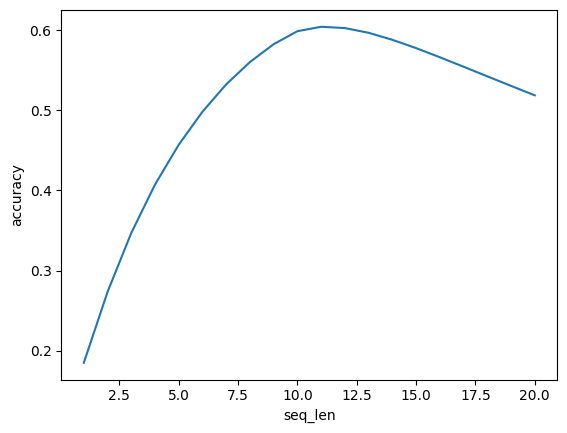

In [35]:
plot_seq_to(20)

In [19]:
model.evaluate(X2,y2)

18232/18232 ━━━━━━━━━━━━━━━━━━━━ 75s 4ms/step - accuracy: 0.5985 - loss: 2.0385


[2.038454055786133, 0.5984697937965393]

In [20]:
def temp_pred(last_word_proba,temp):
    preds=last_word_proba.copy()
    preds = np.asarray(preds).astype('float64')
    preds = np.log(preds + 1e-7) / temp
    exp_preds = np.exp(preds)
    preds = exp_preds / np.sum(exp_preds)
    probas = np.random.multinomial(1, preds, 1)
    return np.argmax(probas)

def next_word(ws_test,mode,temp=0.5):
    seq=np.array([ws_test])
    prediction=model.predict(seq)
    last_word_proba=prediction[0, -1, :]
    next_word_id=""
    if mode == "soft":
        next_word_id = np.random.choice(len(last_word_proba), p=last_word_proba)
    elif mode=="temp":
        next_word_id = temp_pred(last_word_proba,temp)
    else:
        if mode == "many":
            best_word_dict={id_to_word[i+1]:last_word_proba[i+1] for i in range(len(last_word_proba)-1)}
            best_word_list=[(k, best_word_dict[k]) for k in sorted(best_word_dict, key=best_word_dict.get, reverse=True)]
            print(best_word_list[:10])
        next_word_id = np.argmax(last_word_proba)
    #print(id_to_word[next_word_id],last_word_proba[next_word_id])
    return next_word_id
def generate_me_bible(S,n,mode="soft",temp=0.5):
    Tab=np.array(S.split(" "))
    ws_test=[word_to_id[w] for w in Tab]
    for i in range(n):
        next=next_word(ws_test,mode,temp)
        ws_test.append(next)
    result=""
    for w in ws_test:
        result+=id_to_word[w]+" "
    return result

In [28]:
G=generate_me_bible("z ziemi",40,"many",0.25)
print(G)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[(np.str_('egiptu'), np.float32(0.39575198)), (np.str_('i'), np.float32(0.06273822)), (np.str_('północnej'), np.float32(0.03832131)), (np.str_('a'), np.float32(0.027134538)), (np.str_('judy'), np.float32(0.021028133)), (np.str_('kanaan'), np.float32(0.019867528)), (np.str_('którą'), np.float32(0.018927973)), (np.str_('do'), np.float32(0.01532953)), (np.str_('gdy'), np.float32(0.014264664)), (np.str_('chaldejczyków'), np.float32(0.011977561))]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[(np.str_('i'), np.float32(0.15522838)), (np.str_('a'), np.float32(0.04961369)), (np.str_('aby'), np.float32(0.04165969)), (np.str_('z'), np.float32(0.033860467)), (np.str_('w'), np.float32(0.027519196)), (np.str_('przez'), np.float32(0.026006987)), (np.str_('nie'), np.float32(0.024857778)), (np.str_('bo'), np.float32(0.022908187)), (np.str_('aż'), np.float32(0.019585598)), (np.str_('potem'), np.float32(0.018763456))]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
[(np.str_('z'), n